# Lecture 1: Generalized Means — Computational Lab

**Course**: Constant Elasticity Dynamics  
**Instructor**: Saki Bigio, UCLA

---

This notebook accompanies the theory lecture on generalized means. Our goals are:

1. **Learn Julia fundamentals** through the lens of CES aggregators
2. **Build intuition** for how the parameter $\rho$ shapes aggregation
3. **Verify analytical results** numerically
4. **Visualize** iso-mean curves and transformations

By the end, you will have implemented the generalized mean and used it to explore the geometry of CES preferences.

## Part 1: Julia Fundamentals via Building Blocks

We introduce Julia's type system and basic operations using the components of generalized means.

## 1.0 Display Basic Text

In [2]:
println("Hello Wolrd")

Hello Wolrd


### 1.1 Scalars and Types

Julia is a strongly-typed language, but types are usually inferred automatically. Let's define the key parameters.

In [3]:
# The mean-form parameter ρ
ρ = 0.5
a = Int(5)

# Check its type
println("ρ = $ρ")
println("Type of ρ: ", typeof(ρ))
println("a = $a")
println("Type of a: ", typeof(a))

b=a+ρ;
println("Type of b: ", typeof(b))



ρ = 0.5
Type of ρ: Float64
a = 5
Type of a: Int64
Type of b: Float64


In [4]:
# Julia supports Unicode! You can type ρ as \rho<TAB>
# Other useful symbols:
# ω = \omega<TAB>
# ε = \varepsilon<TAB>
# ∑ = \sum<TAB>

# The elasticity of substitution
ε = 1 / (1 - ρ)  # When ρ = 0.5, ε = 2
println("Elasticity ε = $ε")

Elasticity ε = 2.0


In [5]:
# Integer vs Float distinction matters for some operations
n_goods = 2        # Integer
weight = 0.6       # Float64 (default)

println("n_goods: ", typeof(n_goods))
println("weight: ", typeof(weight))

n_goods: Int64
weight: Float64


### 1.2 Vectors: Consumption Bundles and Weights

A consumption bundle $\mathbf{x} = (x_1, x_2)$ and weight vector $\boldsymbol{\omega} = (\omega_1, \omega_2)$ are naturally represented as vectors.

In [6]:
# Define vectors using square brackets
x = [2.0, 3.0]     # Consumption bundle
ω = [0.6, 0.4]     # Weights (should sum to 1 for classical mean)

println("Consumption bundle x = ", x)
println("Weights ω = ", ω)
println("Sum of weights: ", sum(ω))

Consumption bundle x = [2.0, 3.0]
Weights ω = [0.6, 0.4]
Sum of weights: 1.0


In [7]:
# Accessing elements (1-indexed in Julia!)
println("First good: x₁ = ", x[1])
println("Second good: x₂ = ", x[2])

# Vector length
println("Number of goods: ", length(x))

First good: x₁ = 2.0
Second good: x₂ = 3.0
Number of goods: 2


In [8]:
# Creating vectors in different ways
zeros_vec = zeros(3)           # [0.0, 0.0, 0.0]
ones_vec = ones(2)             # [1.0, 1.0, 1.0, 1.0]
range_vec = collect(10:-2:0)       # [1, 2, 3, 4, 5]
linspace_vec = range(0, 1, length=5) |> collect  # [0.0, 0.25, 0.5, 0.75, 1.0]

println("Zeros: ", zeros_vec)
println("Ones: ", ones_vec)
println("Range: ", range_vec)
println("Linspace: ", linspace_vec)

Zeros: [0.0, 0.0, 0.0]
Ones: [1.0, 1.0]
Range: [10, 8, 6, 4, 2, 0]
Linspace: [0.0, 0.25, 0.5, 0.75, 1.0]


### 1.3 Element-wise Operations and Broadcasting

The transformation $\phi_\rho(x) = x^\rho$ must be applied to each element of a vector. Julia uses the **dot syntax** for broadcasting.

In [9]:
# Element-wise power: the dot broadcasts the operation
x = [2.0, 3.0]
ρ = 0.5

# Apply φ(x) = x^ρ to each element
ϕ_x = x .^ ρ

println("x = ", x)
println("ρ = ", ρ)
println("x.^ρ = ", ϕ_x)
println("Verify: 2^0.5 = ", 2^0.5, ", 3^0.5 = ", 3^0.5)

ones_vec'*x

x = [2.0, 3.0]
ρ = 0.5
x.^ρ = [1.4142135623730951, 1.7320508075688772]
Verify: 2^0.5 = 1.4142135623730951, 3^0.5 = 1.7320508075688772


5.0

In [10]:
# Element-wise multiplication
ω = [0.6, 0.4]

# ω .* x gives [ω₁x₁, ω₂x₂]
println("Element-wise product ω .* x = ", ω .* x)
println("Product ω'  x = ", ω' * x)

# This is different from the dot product!
using LinearAlgebra
println("Dot product ω ⋅ x = ", dot(ω, x))

Element-wise product ω .* x = [1.2, 1.2000000000000002]
Product ω'  x = 2.4
Dot product ω ⋅ x = 2.4


In [11]:
# The inner sum of the classical mean: ∑ᵢ ωᵢ xᵢ^ρ
# This is a dot product between ω and x.^ρ

inner_sum = dot(ω, x .^ ρ)
println("Inner sum S̄ = ∑ᵢ ωᵢ xᵢ^ρ = ", inner_sum)

# Equivalently:
inner_sum_v2 = sum(ω .* (x .^ ρ))
println("Using sum(): ", inner_sum_v2)

Inner sum S̄ = ∑ᵢ ωᵢ xᵢ^ρ = 1.5413484604514078
Using sum(): 1.5413484604514078


---

## Part 2: Defining Functions

Now we build up the generalized mean function step by step.

### 2.1 The Transformation Function $\phi_\rho$

The power transformation is the key building block:
$$\phi_\rho(x) = x^\rho, \qquad \phi_\rho^{-1}(y) = y^{1/\rho}$$

In [12]:
# Define the transformation and its inverse
ϕ(x, ρ) = x^ρ
ϕ_inv(y, ρ) = y^(1/ρ)

# Test: ϕ_inv(ϕ(x)) should equal x
x_test = 2.5
ρ_test = 0.7
println("x = ", x_test)
println("ϕ(x) = ", ϕ(x_test, ρ_test))
println("ϕ⁻¹(ϕ(x)) = ", ϕ_inv(ϕ(x_test, ρ_test), ρ_test))

x = 2.5
ϕ(x) = 1.8991444823309347
ϕ⁻¹(ϕ(x)) = 2.5


In [13]:
# Vectorized version using broadcasting
# Note: We just use the dot syntax when calling the function
x_vec = [1.0, 2.0, 3.0, 4.0]

println("x = ", x_vec)
println("ϕ.(x, ρ) = ", ϕ.(x_vec, ρ_test))  # Broadcasts over x_vec

x = [1.0, 2.0, 3.0, 4.0]
ϕ.(x, ρ) = [1.0, 1.624504792712471, 2.157669279974593, 2.6390158215457884]


### 2.2 The Classical Generalized Mean

The classical form is:
$$\bar{\mathcal{M}}(\mathbf{x}; \boldsymbol{\omega}, \rho) = \left( \sum_i \omega_i x_i^\rho \right)^{1/\rho}$$

In [14]:
"""
    classical_mean(x, ω, ρ)

Compute the classical generalized mean (power mean).

# Arguments
- `x::Vector`: consumption bundle or values to aggregate
- `ω::Vector`: weights (should sum to 1)
- `ρ::Real`: mean-form parameter (ρ ≠ 0 for now)

# Returns
- The classical mean M̄(x; ω, ρ)
"""
function classical_mean(x, ω, ρ)
    inner_sum = dot(ω, x .^ ρ)   # ∑ᵢ ωᵢ xᵢ^ρ
    return inner_sum^(1/ρ)        # (∑ᵢ ωᵢ xᵢ^ρ)^(1/ρ)
end

classical_mean

In [15]:
# Test with equal weights: should give familiar means
x = [2.0, 8.0]
ω_equal = [0.5, 0.5]

println("x = ", x)
println("Equal weights ω = ", ω_equal)
println()
println("ρ = 1 (Arithmetic): M̄ = ", classical_mean(x, ω_equal, 1.0))
println("Expected: (2 + 8)/2 = ", (2 + 8)/2)
println()
println("ρ = -1 (Harmonic): M̄ = ", classical_mean(x, ω_equal, -1.0))
println("Expected: 2/(1/2 + 1/8) = ", 2/(1/2 + 1/8))
println()
println("ρ = 2 (Quadratic): M̄ = ", classical_mean(x, ω_equal, 2.0))
println("Expected: √((4 + 64)/2) = ", sqrt((4 + 64)/2))

x = [2.0, 8.0]
Equal weights ω = [0.5, 0.5]

ρ = 1 (Arithmetic): M̄ = 5.0
Expected: (2 + 8)/2 = 5.0

ρ = -1 (Harmonic): M̄ = 3.2
Expected: 2/(1/2 + 1/8) = 3.2

ρ = 2 (Quadratic): M̄ = 5.830951894845301
Expected: √((4 + 64)/2) = 5.830951894845301


### 2.3 Handling Special Cases: $\rho \to 0, \pm\infty$

The classical mean has important limiting cases:
- **$\rho \to 0$**: Geometric mean $\prod_i x_i^{\omega_i}$
- **$\rho \to -\infty$**: Minimum $\min_i x_i$
- **$\rho \to +\infty$**: Maximum $\max_i x_i$

In [16]:
"""
    classical_mean_full(x, ω, ρ; tol=1e-10)

Compute the classical generalized mean, handling special cases.

# Arguments
- `x::Vector`: values to aggregate (must be positive)
- `ω::Vector`: weights (should sum to 1)
- `ρ::Real`: mean-form parameter
- `tol::Real`: tolerance for detecting ρ ≈ 0

# Special cases
- ρ ≈ 0: Returns geometric mean
- ρ = -Inf: Returns minimum
- ρ = +Inf: Returns maximum
"""
function classical_mean_full(x, ω, ρ; tol=1e-10)
    # Check inputs
    @assert all(x .> 0) "All x values must be positive"
    @assert length(x) == length(ω) "x and ω must have same length"
    
    # Special case: ρ → 0 (geometric mean)
    if abs(ρ) < tol
        return prod(x .^ ω)  # ∏ᵢ xᵢ^ωᵢ
    end
    
    # Special case: ρ → -∞ (minimum)
    if ρ == -Inf
        return minimum(x)
    end
    
    # Special case: ρ → +∞ (maximum)
    if ρ == Inf
        return maximum(x)
    end
    
    # General case
    inner_sum = dot(ω, x .^ ρ)
    return inner_sum^(1/ρ)
end

classical_mean_full

In [17]:
# Test the special cases
x = [2.0, 8.0]
ω = [0.5, 0.5]

println("Testing special cases with x = $x, ω = $ω")
println()
println("ρ → 0 (Geometric): M̄ = ", classical_mean_full(x, ω, 0.0))
println("Expected: √(2 × 8) = ", sqrt(2 * 8))
println(classical_mean_full(x, ω, 0.0)==sqrt(2 * 8))
println()
println("ρ → -∞ (Min): M̄ = ", classical_mean_full(x, ω, -Inf))
println("Expected: min(2, 8) = ", minimum(x))
println()
println("ρ → +∞ (Max): M̄ = ", classical_mean_full(x, ω, Inf))
println("Expected: max(2, 8) = ", maximum(x))

Testing special cases with x = [2.0, 8.0], ω = [0.5, 0.5]

ρ → 0 (Geometric): M̄ = 4.000000000000001
Expected: √(2 × 8) = 4.0
false

ρ → -∞ (Min): M̄ = 2.0
Expected: min(2, 8) = 2.0

ρ → +∞ (Max): M̄ = 8.0
Expected: max(2, 8) = 8.0


In [18]:
# Verify the ordering property: ρ < ρ' implies M̄_ρ < M̄_ρ'
# (when not all x_i are equal)

ρ_values = [-10.0, -1.0, 0.0, 0.5, 1.0, 2.0, 10.0]
means = [classical_mean_full(x, ω, ρ) for ρ in ρ_values]

println("Ordering property verification:")
println("-" ^ 30)
for (ρ, m) in zip(ρ_values, means)
    println("ρ = $(lpad(ρ, 5))  →  M̄ = $(round(m, digits=4))")
end
println("-" ^ 30)
println("Means are strictly increasing: ", issorted(means))

for n=1:length(ρ_values)
    println("ρ = $(ρ_values[n])  ")
end

Ordering property verification:
------------------------------
ρ = -10.0  →  M̄ = 2.1435
ρ =  -1.0  →  M̄ = 3.2
ρ =   0.0  →  M̄ = 4.0
ρ =   0.5  →  M̄ = 4.5
ρ =   1.0  →  M̄ = 5.0
ρ =   2.0  →  M̄ = 5.831
ρ =  10.0  →  M̄ = 7.4643
------------------------------
Means are strictly increasing: true
ρ = -10.0  
ρ = -1.0  
ρ = 0.0  
ρ = 0.5  
ρ = 1.0  
ρ = 2.0  
ρ = 10.0  


### 2.4 The Canonical Generalized Mean

The canonical form from the lecture notes:
$$\mathcal{M}(\mathbf{x}; \boldsymbol{\omega}, \rho) = \left( \sum_i \omega_i^{1-\rho} x_i^\rho \right)^{1/\rho}$$

Nothing special. Just defining. 

In [19]:
"""
    canonical_mean(x, ω, ρ; tol=1e-10)

Compute the canonical generalized mean.

The canonical form uses weights ω^(1-ρ) inside the sum, which ensures
that M(ω, ω, ..., ω; ω, ρ) = 1 (constant for x_i = ω_i).
"""
function canonical_mean(x, ω, ρ; tol=1e-10)
    @assert all(x .> 0) "All x values must be positive"
    @assert all(ω .> 0) "All weights must be positive"
    @assert length(x) == length(ω) "x and ω must have same length"
    
    # Special case: ρ → 0 (geometric mean with canonical weights)
    if abs(ρ) < tol
        # Limit gives: ∏ᵢ xᵢ^ωᵢ (same as classical geometric)
        ω_normalized = ω ./ sum(ω)
        return prod(x .^ ω_normalized)
    end
    
    # General case: (∑ᵢ ωᵢ^(1-ρ) xᵢ^ρ)^(1/ρ)
    inner_sum = sum((ω .^ (1 - ρ)) .* (x .^ ρ))
    return inner_sum^(1/ρ)
end

canonical_mean

In [20]:
# Key property of canonical form: M(ω; ω, ρ) is constant across ρ
ω = [0.6, 0.4]

println("Testing canonical mean at x = ω:")
println("ω = ", ω)
println()
for ρ in [-2.0, -1.0, 0.5, 1.0, 2.0]
    m = canonical_mean(ω, ω, ρ)
    println("ρ = $(lpad(ρ, 4))  →  M(ω; ω, ρ) = $(round(m, digits=6))")
end
println()
println("All values equal 1.0 (up to numerical precision)")

Testing canonical mean at x = ω:
ω = [0.6, 0.4]

ρ = -2.0  →  M(ω; ω, ρ) = 1.0
ρ = -1.0  →  M(ω; ω, ρ) = 1.0
ρ =  0.5  →  M(ω; ω, ρ) = 1.0
ρ =  1.0  →  M(ω; ω, ρ) = 1.0
ρ =  2.0  →  M(ω; ω, ρ) = 1.0

All values equal 1.0 (up to numerical precision)


---

## Part 3: Visualization

Now we visualize the generalized mean and its level curves.

In [21]:
using Plots
gr()  # Use the GR backend for fast plotting

Plots.GRBackend()

### 3.1 The Mean as a Function of $\rho$

Fix a consumption bundle and weights, then plot $\mathcal{M}(\mathbf{x}; \boldsymbol{\omega}, \rho)$ as $\rho$ varies.

In [25]:
# Fix x and ω
x = [2.0, 5.0]
ω = [0.5, 0.5]
println("value of x element 1: ", x[1])

# Range of ρ values (avoid exactly 0)
ρ_range = vcat(range(-5, -0.01, length=100), range(0.01, 5, length=100))

# Compute means
means_classical = [classical_mean_full(x, ω, ρ) for ρ in ρ_range]
means_canonical = [canonical_mean(x, ω, ρ) for ρ in ρ_range]

# Special values
geom_mean = sqrt(prod(x))  # Equal weights geometric mean
arith_mean = sum(ω .* x)
harm_mean = 1 / sum(ω ./ x)

value of x element 1: 2.0


2.857142857142857

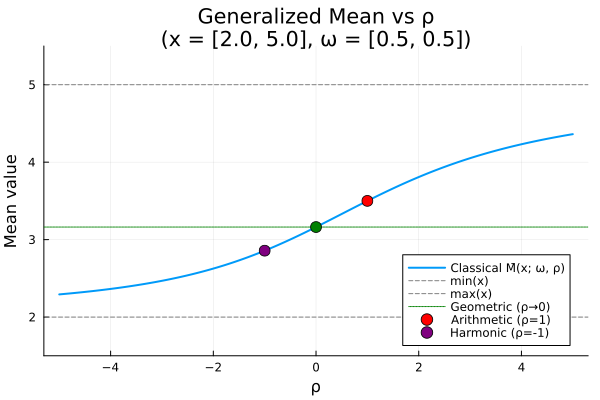

In [26]:
p1 = plot(ρ_range, means_classical, 
    label="Classical M̄(x; ω, ρ)",
    xlabel="ρ", ylabel="Mean value",
    title="Generalized Mean vs ρ\n(x = $x, ω = $ω)",
    linewidth=2,
    legend=:bottomright)

# Add horizontal lines for special means
hline!([minimum(x)], linestyle=:dash, color=:gray, label="min(x)")
hline!([maximum(x)], linestyle=:dash, color=:gray, label="max(x)")
hline!([geom_mean], linestyle=:dot, color=:green, label="Geometric (ρ→0)")

# Mark special points
scatter!([0], [geom_mean], markersize=6, color=:green, label="")
scatter!([1], [arith_mean], markersize=6, color=:red, label="Arithmetic (ρ=1)")
scatter!([-1], [harm_mean], markersize=6, color=:purple, label="Harmonic (ρ=-1)")

ylims!(minimum(x) - 0.5, maximum(x) + 0.5)
p1

**Observation**: As $\rho$ increases from $-\infty$ to $+\infty$, the mean interpolates monotonically from $\min(x)$ to $\max(x)$. This is the **ordering property**.

### 3.2 The Transformation $\phi_\rho(x) = x^\rho$

Understanding how $\phi_\rho$ transforms the data is key to understanding generalized means.

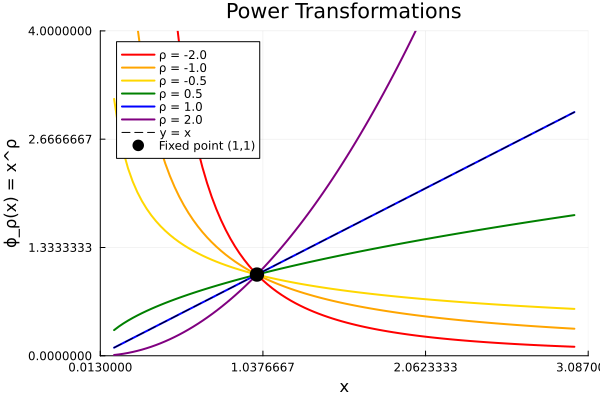

┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/package

In [ ]:
x_grid = range(0.1, 3, length=100)
ρ_values = [-2, -1, -0.5, 0.5, 1, 2]

p2 = plot(xlabel="x", ylabel="ϕ_ρ(x) = x^ρ",
    title="Power Transformations",
    legend=:topleft)

colors = [:red, :orange, :gold, :green, :blue, :purple]

for (i, ρ) in enumerate(ρ_values)
    y = x_grid .^ ρ
    plot!(x_grid, y, label="ρ = $ρ", linewidth=2, color=colors[i])
end

# Add reference line y = x (ρ = 1)
plot!(x_grid, x_grid, linestyle=:dash, color=:black, label="y = x", linewidth=1)

# Mark the fixed point x = 1
scatter!([1], [1], markersize=8, color=:black, label="Fixed point (1,1)")

ylims!(0, 4)
p2

**Key observations**:
- All curves pass through $(1, 1)$: this is the fixed point $\phi_\rho(1) = 1$ for all $\rho$
- $\rho > 1$: Convex, amplifies differences (values $> 1$ grow faster)
- $0 < \rho < 1$: Concave, compresses differences
- $\rho < 0$: Decreasing, inverts the order (large $x$ maps to small $\phi(x)$)

### 3.3 Iso-Mean Curves via Contour Plots

An **iso-mean curve** (or indifference curve in utility terms) is the set of bundles $(x_1, x_2)$ with the same mean value:
$$\{(x_1, x_2) : \mathcal{M}(x_1, x_2; \omega, \rho) = m\}$$

In [27]:
# Create a grid
x1_grid = range(0.1, 4, length=100)
x2_grid = range(0.1, 4, length=100)

# Weight
ω = [0.5, 0.5]

# Function to compute mean on a grid
function compute_mean_grid(x1_grid, x2_grid, ω, ρ; form=:classical)
    mean_func = form == :classical ? classical_mean_full : canonical_mean
    Z = [mean_func([x1, x2], ω, ρ) for x2 in x2_grid, x1 in x1_grid]
    return Z
end

compute_mean_grid (generic function with 1 method)

┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/package

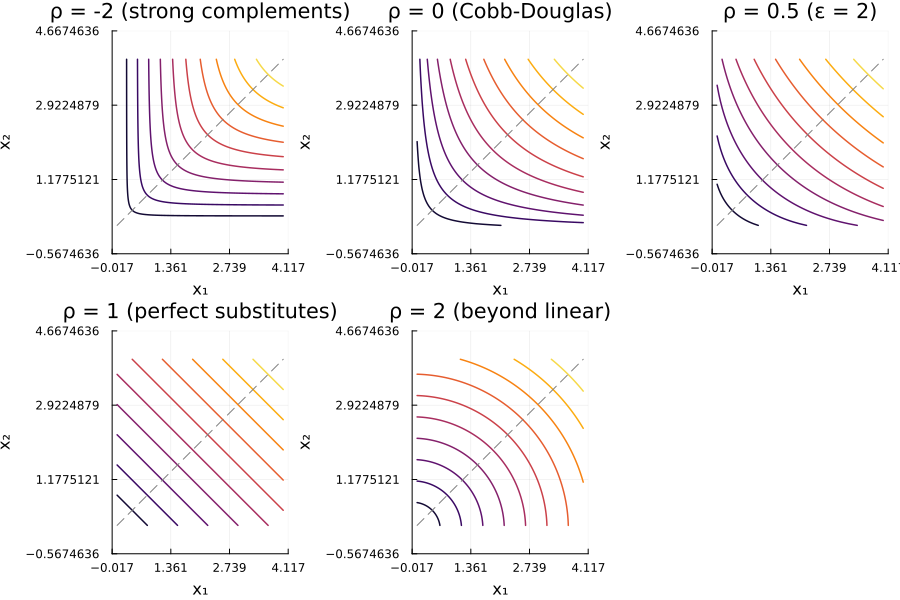

In [ ]:
# Compare iso-curves for different ρ values
ρ_examples = [-2.0, 0.0, 0.5, 1.0, 2.0]  # Complements to substitutes
titles = ["ρ = -2 (strong complements)", 
          "ρ = 0 (Cobb-Douglas)",
          "ρ = 0.5 (ε = 2)",
          "ρ = 1 (perfect substitutes)",
          "ρ = 2 (beyond linear)"]

plots_iso = []

for (ρ, ttl) in zip(ρ_examples, titles)
    Z = compute_mean_grid(x1_grid, x2_grid, ω, ρ)
    
    p = contour(x1_grid, x2_grid, Z,
        levels=10,
        xlabel="x₁", ylabel="x₂",
        title=ttl,
        aspect_ratio=:equal,
        colorbar=false,
        linewidth=1.5)
    
    # Add the 45-degree line
    plot!(x1_grid, x1_grid, linestyle=:dash, color=:gray, label="", linewidth=1)
    
    push!(plots_iso, p)
end

plot(plots_iso..., layout=(2, 3), size=(900, 600))

**Interpretation**:
- **$\rho < 0$** (complements): Curves bend toward the origin, approaching L-shaped (Leontief) as $\rho \to -\infty$
- **$\rho = 0$** (Cobb-Douglas): Classic hyperbolic indifference curves
- **$\rho = 1$** (perfect substitutes): Linear indifference curves
- **$\rho > 1$**: Curves bend outward (convex to origin), representing goods that are "super-substitutes"

### 3.4 Iso-Mean Curves: Manual Computation

Now we compute the curves manually. This reveals the underlying structure and prepares us for the transformation approach.

For a classical mean level $\bar{m}$, we solve for $x_2$ as a function of $x_1$:
$$\bar{m}^\rho = \omega_1 x_1^\rho + \omega_2 x_2^\rho$$
$$x_2 = \left( \frac{\bar{m}^\rho - \omega_1 x_1^\rho}{\omega_2} \right)^{1/\rho}$$

In [ ]:
"""
    isocurve_classical(x1, m̄, ω, ρ)

Compute x₂ on the iso-mean curve for classical mean level m̄.
Returns NaN if no valid solution exists (budget exhausted).
"""
function isocurve_classical(x1, m̄, ω, ρ)
    ω1, ω2 = ω
    
    # Handle ρ → 0 (geometric mean) separately
    if abs(ρ) < 1e-10
        # m̄ = x₁^ω₁ x₂^ω₂  →  x₂ = (m̄ / x₁^ω₁)^(1/ω₂)
        return (m̄ / x1^ω1)^(1/ω2)
    end
    
    # General case: m̄^ρ = ω₁x₁^ρ + ω₂x₂^ρ
    numerator = m̄^ρ - ω1 * x1^ρ
    
    # Check if solution exists
    if numerator ≤ 0
        return NaN
    end
    
    x2_rho = numerator / ω2
    return x2_rho^(1/ρ)
end

isocurve_classical

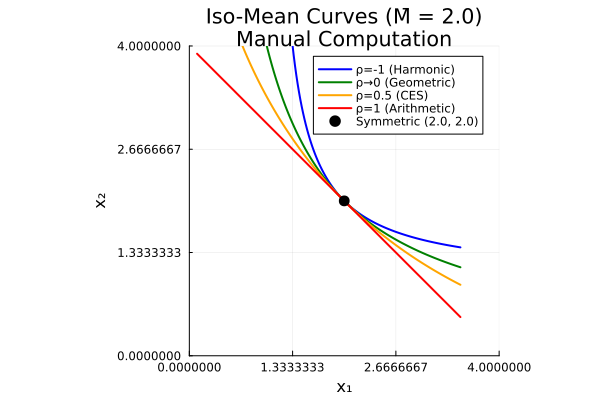

┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/package

In [ ]:
# Plot iso-curves manually for different ρ values
ω = [0.5, 0.5]
m̄_target = 2.0  # Target mean level

x1_vals = range(0.1, 3.5, length=200)

p_manual = plot(xlabel="x₁", ylabel="x₂",
    title="Iso-Mean Curves (M̄ = $m̄_target)\nManual Computation",
    aspect_ratio=:equal,
    legend=:topright)

ρ_examples = [-1.0, 0.0, 0.5, 1.0]
colors = [:blue, :green, :orange, :red]
labels = ["ρ=-1 (Harmonic)", "ρ→0 (Geometric)", "ρ=0.5 (CES)", "ρ=1 (Arithmetic)"]

for (ρ, col, lab) in zip(ρ_examples, colors, labels)
    x2_vals = [isocurve_classical(x1, m̄_target, ω, ρ) for x1 in x1_vals]
    
    # Filter out NaN values
    valid = .!isnan.(x2_vals)
    
    plot!(x1_vals[valid], x2_vals[valid], 
        label=lab, linewidth=2, color=col)
end

# Mark the symmetric point (where x₁ = x₂ = m̄ for equal weights)
scatter!([m̄_target], [m̄_target], markersize=6, color=:black, 
    label="Symmetric ($(m̄_target), $(m̄_target))")

xlims!(0, 4)
ylims!(0, 4)
p_manual

### 3.5 The Transformation Perspective: "Straightening" the Curves

Here's the key insight: in **transformed coordinates** $y_i = \phi_\rho(x_i) = x_i^\rho$, the iso-mean curves become **hyperplanes** (straight lines in 2D)!

The classical mean condition:
$$\bar{m}^\rho = \omega_1 x_1^\rho + \omega_2 x_2^\rho$$

Becomes:
$$\bar{m}^\rho = \omega_1 y_1 + \omega_2 y_2 \quad \text{(a linear equation in } y\text{-space)}$$

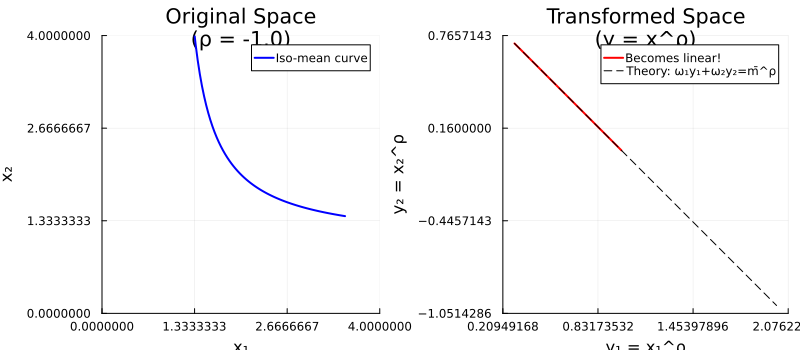

┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/package

In [ ]:
# Demonstrate the straightening effect

ρ = -1.0  # Harmonic mean (curved in x-space)
m̄ = 2.0
ω = [0.5, 0.5]

# Compute curve in x-space
x1_vals = range(0.5, 3.5, length=100)
x2_vals = [isocurve_classical(x1, m̄, ω, ρ) for x1 in x1_vals]

# Transform to y-space: y = x^ρ
y1_vals = x1_vals .^ ρ
y2_vals = x2_vals .^ ρ

# Plot side by side
p_orig = plot(x1_vals, x2_vals,
    xlabel="x₁", ylabel="x₂",
    title="Original Space\n(ρ = $ρ)",
    linewidth=2, color=:blue,
    aspect_ratio=:equal,
    label="Iso-mean curve",
    legend=:topright)
xlims!(0, 4)
ylims!(0, 4)

p_trans = plot(y1_vals, y2_vals,
    xlabel="y₁ = x₁^ρ", ylabel="y₂ = x₂^ρ",
    title="Transformed Space\n(y = x^ρ)",
    linewidth=2, color=:red,
    aspect_ratio=:equal,
    label="Becomes linear!",
    legend=:topright)

# Add the theoretical line: ω₁y₁ + ω₂y₂ = m̄^ρ
y1_line = range(minimum(y1_vals), maximum(y1_vals), length=50)
y2_line = (m̄^ρ .- ω[1] .* y1_line) ./ ω[2]
plot!(p_trans, y1_line, y2_line, linestyle=:dash, color=:black, label="Theory: ω₁y₁+ω₂y₂=m̄^ρ")

plot(p_orig, p_trans, layout=(1, 2), size=(800, 350))

**This is the central insight**: The power transformation "straightens" the indifference curves. In the transformed $y$-space, the consumer has linear preferences, making optimization straightforward.

### 3.6 Scaling and the Transformation

When we scale the mean level from $\bar{m}$ to $\lambda \bar{m}$:
- In $x$-space: curves shift outward in a complex way
- In $y$-space: the hyperplane shifts by a simple multiplicative factor

Specifically, if $\omega_1 y_1 + \omega_2 y_2 = \bar{m}^\rho$, then scaling gives:
$$\omega_1 y_1 + \omega_2 y_2 = (\lambda \bar{m})^\rho = \lambda^\rho \bar{m}^\rho$$

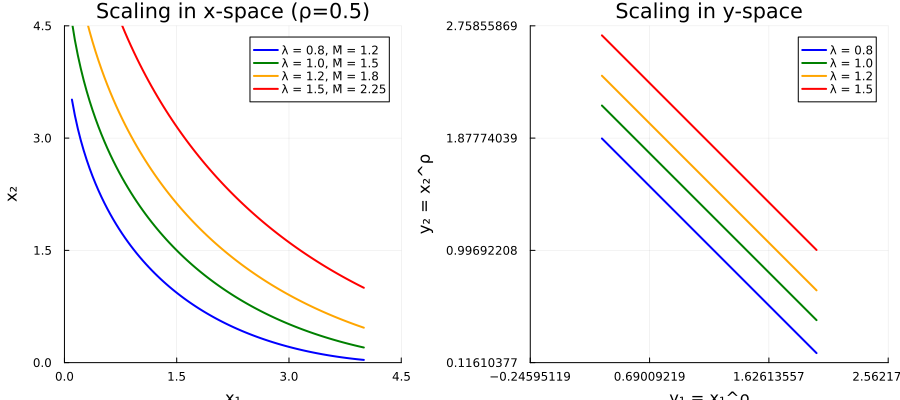

┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/packages/PlotUtils/M092a/src/ticks.jl:191
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/sakiclaudia/.julia/package

In [ ]:
# Show how scaling works in both spaces
ρ = 0.5
ω = [0.5, 0.5]
m̄_base = 1.5
λ_values = [0.8, 1.0, 1.2, 1.5]

x1_vals = range(0.1, 4, length=100)

p_scale_x = plot(xlabel="x₁", ylabel="x₂", 
    title="Scaling in x-space (ρ=$ρ)",
    aspect_ratio=:equal, legend=:topright)

p_scale_y = plot(xlabel="y₁ = x₁^ρ", ylabel="y₂ = x₂^ρ",
    title="Scaling in y-space",
    aspect_ratio=:equal, legend=:topright)

colors = [:blue, :green, :orange, :red]

for (λ, col) in zip(λ_values, colors)
    m̄ = λ * m̄_base
    
    x2_vals = [isocurve_classical(x1, m̄, ω, ρ) for x1 in x1_vals]
    valid = .!isnan.(x2_vals)
    
    # x-space
    plot!(p_scale_x, x1_vals[valid], x2_vals[valid],
        label="λ = $λ, M̄ = $(round(m̄, digits=2))", 
        linewidth=2, color=col)
    
    # y-space
    y1 = x1_vals[valid] .^ ρ
    y2 = x2_vals[valid] .^ ρ
    plot!(p_scale_y, y1, y2, label="λ = $λ", linewidth=2, color=col)
end

xlims!(p_scale_x, 0, 4.5)
ylims!(p_scale_x, 0, 4.5)

plot(p_scale_x, p_scale_y, layout=(1, 2), size=(900, 400))

---

## Part 4: Exercises

### Exercise 1: The Canonical Mean
Implement the transformation from canonical to classical form:
$$\mathcal{M}(\mathbf{x}; \boldsymbol{\omega}, \rho) = \lambda(\boldsymbol{\omega}, \rho) \cdot \bar{\mathcal{M}}(\mathbf{x}; \tilde{\boldsymbol{\omega}}, \rho)$$
where $\lambda$ and $\tilde{\omega}$ are defined in the notes.

### Exercise 2: Numerical Verification
Verify that $\frac{\partial \mathcal{M}}{\partial \rho} > 0$ numerically using finite differences.

### Exercise 3: MRS Computation
Compute and plot the marginal rate of substitution:
$$\text{MRS}_{12} = \frac{\partial \mathcal{M}/\partial x_1}{\partial \mathcal{M}/\partial x_2}$$
along an indifference curve for different $\rho$ values.

### Exercise 4: Python Implementation
Translate the `classical_mean_full` function to Python using NumPy. Compare execution times for large vectors.

---

## References

- Lecture notes: *Constant Elasticity Dynamics*, Chapter 1
- QuantEcon lectures: [Julia Fundamentals](https://julia.quantecon.org/getting_started_julia/julia_by_example.html)
- QuantEcon lectures: [Arrays and Vectors](https://julia.quantecon.org/getting_started_julia/arrays_operations.html)